# 03 · Tuning and scoring

Notebook 02 built a working nowcast with three choices made by hand:

1. **how `R_t` is set**: relative noise per hour, `R_t = (s_t × x⁻)²`
2. **one arrival curve** `f_t` for every day
3. **process noise**: `Q = 0`, so nothing unexpected can happen during the day

Here we test alternatives and score them honestly.

### How we score

* **MAE by hour:** mean absolute error of the estimate at each clock hour, in guests.
  The *forecast-only* MAE is the baseline to beat; it doesn't change during the day
  because the forecast doesn't.
* **Coverage:** the share of days where the truth falls inside estimate ± 2σ. If the
  filter's uncertainty is honest, this should be close to **95%**. Lower means the
  filter is *overconfident*; higher means the band is wider than it needs to be.

### Don't tune on the test set

If we picked settings by looking at 2024 and then reported 2024 scores, the scores
would flatter us. So we use three separate periods:

| Period | Used for |
| --- | --- |
| 2022 | estimate `f_t`, `R_t`, forecast error (the "fit" year) |
| 2023 | compare settings and choose (the "validation" year) |
| 2024 | one final score with the chosen settings, refit on 2022–23 (the "test" year) |

⚠️ **All data is SIMULATED** (fictional Tampa, FL park; see notebook 02 and the README).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nowcast import db
from nowcast.arrivals import estimate_curve
from nowcast.daytype import day_type
from nowcast.forecast import same_weekday_forecast, relative_error_sd
from nowcast.noise import implied_errors, noise_by_hour, constant_R, absolute_R, relative_R
from nowcast.runner import nowcast_days
from nowcast.scoring import score_by_hour
from nowcast.style import COLORS, apply_style

apply_style()
pd.set_option("display.precision", 2)

SOURCE = "simulation"
engine = db.get_engine()
PARK_ID = db.ensure_simulated_data(engine)
daily = db.load_daily(engine, PARK_ID, SOURCE)
hourly = db.load_hourly(engine, PARK_ID, SOURCE)

daily["forecast"] = same_weekday_forecast(daily, n_weeks=4)
daily["day_type"] = day_type(daily["visit_date"]).to_numpy()   # "peak" = weekend or FL holiday
print(daily.day_type.value_counts().to_string())

day_type
regular    750
peak       346


## 1. One function to fit everything on a training period

Everything the filter learns from history is fitted in one place, so we can refit it
on different periods without copy-pasting:

* `f_pooled`: one arrival curve for all days (notebook 02)
* `f_by_type`: separate curves for `peak` (weekend/holiday) and `regular` days
* `noise`: implied-total error statistics per hour, for each curve choice
* `s0`: the forecast's relative error sd, which sets `P₀`

In [2]:
def fit(train_days):
    # Learn f_t, R_t statistics and forecast error from the given training days.
    tr_daily = daily[daily.visit_date.isin(train_days)]
    tr_hourly = hourly[hourly.visit_date.isin(train_days)]

    f_pooled = estimate_curve(tr_hourly, tr_daily)
    f_by_type = {}
    for t in ["peak", "regular"]:
        days_t = tr_daily[tr_daily.day_type == t]
        f_by_type[t] = estimate_curve(tr_hourly[tr_hourly.visit_date.isin(days_t.visit_date)], days_t)

    return {
        "f_pooled": f_pooled,
        "f_by_type": f_by_type,
        "noise_pooled": noise_by_hour(implied_errors(tr_hourly, tr_daily, f_pooled)),
        "noise_by_type": noise_by_hour(implied_errors(tr_hourly, tr_daily, f_by_type)),
        "s0": relative_error_sd(tr_daily.attendance, tr_daily.forecast),
    }


def evaluation_days(start, end, s0):
    # Days in [start, end) with a forecast, plus their prior variance P0.
    d = daily[(daily.visit_date >= start) & (daily.visit_date < end)].dropna(subset=["forecast"]).copy()
    d["P0"] = (s0 * d.forecast) ** 2
    return d


fit_2022 = fit(daily.visit_date[daily.visit_date < "2023-01-01"])
val = evaluation_days("2023-01-01", "2024-01-01", fit_2022["s0"])
print(f"forecast relative error sd (2022): {fit_2022['s0']:.3f}")
print(f"validation days (2023): {len(val)}")

forecast relative error sd (2022): 0.206
validation days (2023): 365


## 2. Choice of `R_t` scheme

Three ways to say how noisy the implied total `z_t` is:

| Scheme | Formula | In plain English |
| --- | --- | --- |
| constant | `R_t = R` (one number all day) | "every hour's reading is equally trustworthy" (clearly wrong, but a useful baseline) |
| absolute | `R_t = Var(z_t − final)` per hour, in guests² | "at 11:00 readings are typically off by ±N guests" |
| relative | `R_t = (s_t × x⁻)²` | "at 11:00 readings are typically off by ±s_t %" of today's size |

For the constant scheme we use the median of the hourly absolute variances, a
reasonable "average" hour.

In [3]:
noise = fit_2022["noise_pooled"]
f = fit_2022["f_pooled"]

schemes = {
    "constant": constant_R(float(noise["abs_var"].median())),
    "absolute": absolute_R(noise["abs_var"]),
    "relative": relative_R(noise["rel_sd"]),
}
scheme_scores = {name: score_by_hour(nowcast_days(hourly, val, f, R, q=0.0))
                 for name, R in schemes.items()}

mae_table = pd.DataFrame({"forecast only": scheme_scores["relative"]["mae_forecast"]})
for name, sc in scheme_scores.items():
    mae_table[f"filtered: {name}"] = sc["mae_filtered"]
mae_table.round(0)

,forecast only,filtered: constant,filtered: absolute,filtered: relative
hour,,,,
10,525.0,717.0,498.0,462.0
11,525.0,617.0,473.0,452.0
12,525.0,539.0,422.0,417.0
13,525.0,473.0,351.0,348.0
14,525.0,412.0,249.0,245.0
15,525.0,358.0,147.0,145.0
16,525.0,313.0,71.0,71.0
17,525.0,276.0,23.0,23.0
18,525.0,245.0,0.0,0.0


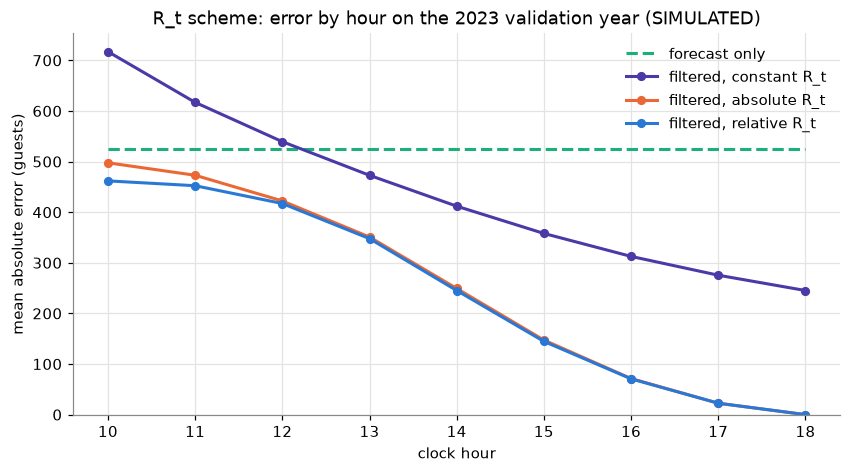

In [4]:
scheme_colors = {"constant": COLORS["alt"], "absolute": COLORS["measurement"], "relative": COLORS["estimate"]}
fig, ax = plt.subplots()
ax.plot(mae_table.index, mae_table["forecast only"], color=COLORS["forecast"], ls="--", label="forecast only")
for name in schemes:
    ax.plot(mae_table.index, mae_table[f"filtered: {name}"], color=scheme_colors[name], marker="o",
            label=f"filtered, {name} R_t")
ax.set_xlabel("clock hour")
ax.set_ylabel("mean absolute error (guests)")
ax.set_ylim(0, None)
ax.set_title("R_t scheme: error by hour on the 2023 validation year (SIMULATED)")
ax.legend()
plt.show()

**What this shows**

* **Constant `R` is worse than no filter at all in the morning.** It trusts the wild
  10:00 implied totals as much as the reliable 15:00 ones, so early noise drags the
  estimate off. Later it trusts good readings too little, and it never converges on
  the truth even at closing. How you model `R_t` matters more than anything else here.
* **Absolute and relative both work.** Relative is better in the morning, because a
  noise level in *percent* carries over between quiet and busy days, while a single
  variance in guests² is too large for a quiet Tuesday and too small for a spring-break
  Saturday.

We keep **relative `R_t`**.

## 3. One arrival curve, or one per day type?

On weekends and holidays, families arrive later. A single pooled curve then
*underestimates* early weekend totals (counts look small because the crowd hasn't
come yet) and *overestimates* early weekday totals. The day type is known before the
gates open, so using it is fair.

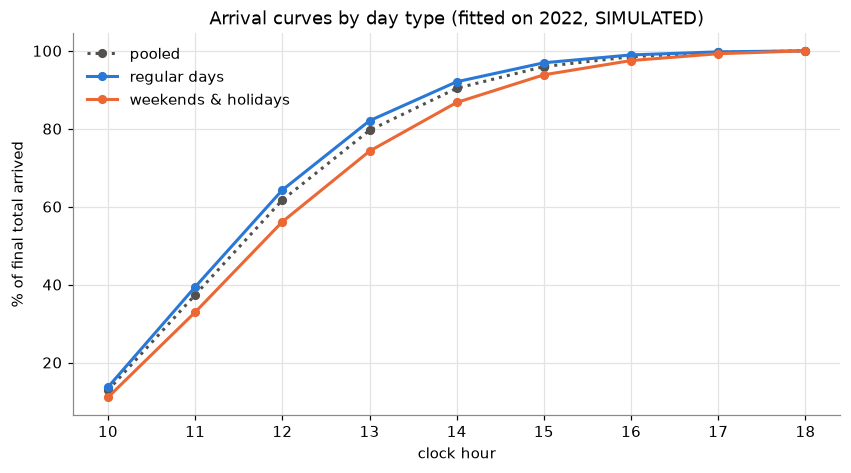

hour,10,11,12,13,14,15,16,17,18
pooled curve,462.0,452.0,417.0,348.0,245.0,145.0,71.0,23.0,0.0
curve by day type,449.0,425.0,383.0,317.0,222.0,130.0,64.0,21.0,0.0


In [5]:
fig, ax = plt.subplots()
ax.plot(f.index, 100 * f, color=COLORS["muted"], ls=":", marker="o", label="pooled")
ax.plot(f.index, 100 * fit_2022["f_by_type"]["regular"], color=COLORS["estimate"], marker="o", label="regular days")
ax.plot(f.index, 100 * fit_2022["f_by_type"]["peak"], color=COLORS["measurement"], marker="o", label="weekends & holidays")
ax.set_xlabel("clock hour")
ax.set_ylabel("% of final total arrived")
ax.set_title("Arrival curves by day type (fitted on 2022, SIMULATED)")
ax.legend()
plt.show()

curve_scores = {
    "pooled curve": scheme_scores["relative"],
    "curve by day type": score_by_hour(nowcast_days(
        hourly, val, fit_2022["f_by_type"], relative_R(fit_2022["noise_by_type"]["rel_sd"]), q=0.0)),
}
pd.DataFrame({name: sc["mae_filtered"] for name, sc in curve_scores.items()}).round(0).T

Separate curves reduce the error at every hour before closing, most of all around
midday. We keep **curves by day type**.

## 4. Process noise `Q`

`Q` is added to the variance at each predict step: "the true final total might have
shifted since the last reading". We set it as a fraction `q` of the current estimate
per hour, `Q = (q × x)²`, so `q = 0.05` means "a ±5% surprise per hour is plausible".

What can shift during the day? In this simulation, afternoon **thunderstorms**: after
a storm, arrivals nearly stop and the day ends below what the morning counts implied.
With `Q = 0` the filter is sure of itself by early afternoon and slow to follow such a
break. (The storm hour comes from the simulation's hidden log. Production data won't
have this column, one reason to tune on simulation first.)

In [6]:
storm_days = db.load_simulation_log(engine, PARK_ID).dropna(subset=["storm_hour"]).visit_date
f_best = fit_2022["f_by_type"]
rel_sd = fit_2022["noise_by_type"]["rel_sd"]
print(f"storm days in 2023 validation: {val.visit_date.isin(storm_days).sum()} of {len(val)}")

q_values = [0.0, 0.05, 0.12, 0.2]
q_colors = [COLORS["alt"], COLORS["measurement"], COLORS["estimate"], COLORS["alt2"]]
q_runs = {q: nowcast_days(hourly, val, f_best, relative_R(rel_sd), q=q) for q in q_values}

rows = []
for q, res in q_runs.items():
    storm = res.visit_date.isin(storm_days)
    rows.append({"q": q,
                 "MAE 10:00 (all)": score_by_hour(res).loc[10, "mae_filtered"],
                 "MAE 14:00 (storm days)": score_by_hour(res[storm]).loc[14, "mae_filtered"],
                 "MAE 14:00 (other days)": score_by_hour(res[~storm]).loc[14, "mae_filtered"]})
pd.DataFrame(rows).set_index("q").round(0)

storm days in 2023 validation: 39 of 365


,MAE 10:00 (all),MAE 14:00 (storm days),MAE 14:00 (other days)
q,,,
0.00,449.0,255.0,218.0
0.05,452.0,234.0,194.0
0.12,464.0,211.0,170.0
0.20,492.0,202.0,162.0


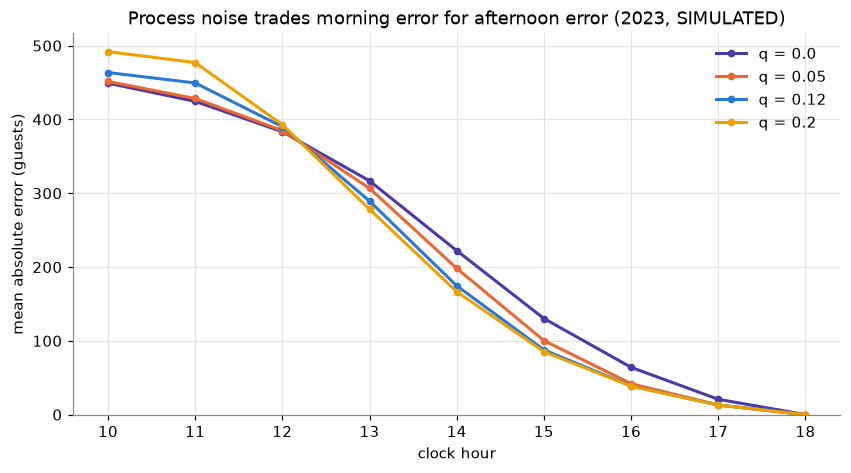

In [7]:
fig, ax = plt.subplots()
for (q, res), color in zip(q_runs.items(), q_colors):
    sc = score_by_hour(res)
    ax.plot(sc.index, sc["mae_filtered"], color=color, marker="o", ms=4, label=f"q = {q}")
ax.set_xlabel("clock hour")
ax.set_ylabel("mean absolute error (guests)")
ax.set_ylim(0, None)
ax.set_title("Process noise trades morning error for afternoon error (2023, SIMULATED)")
ax.legend()
plt.show()

**Reading the Q results (this is not what I expected when I started)**

* Larger `q` cuts the afternoon error on storm days, as intended.
* It cuts the afternoon error on **ordinary days by about the same amount**. So storms
  are not the main thing `Q` is fixing here.
* It *raises* the morning error, because `Q` makes the filter lean harder on the noisy
  early readings.

If `Q` helps on days where nothing changes, the filter must have been too stubborn
for another reason. The next section finds it.

## 5. Is the band honest? Calibration, and a second knob

A ±2σ band should contain the truth on about 95% of days. Here is how often it does,
with `q = 0`:

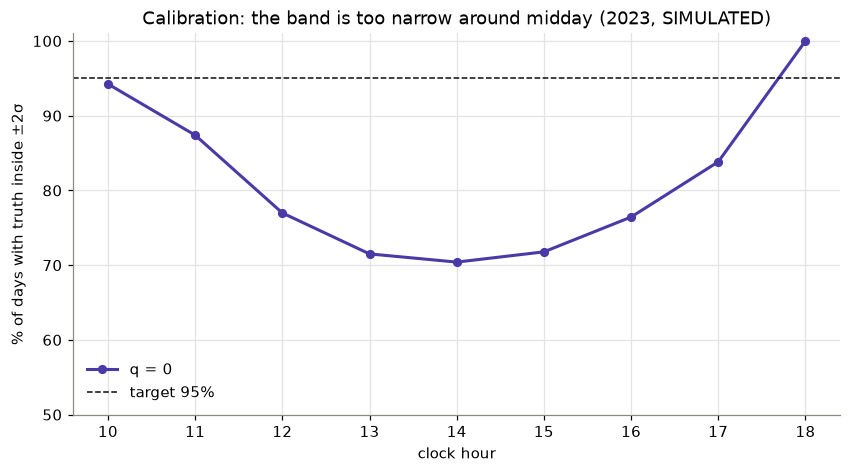

In [8]:
cov_q0 = score_by_hour(q_runs[0.0])["coverage_2sd"]
fig, ax = plt.subplots()
ax.plot(cov_q0.index, 100 * cov_q0, color=COLORS["alt"], marker="o", label="q = 0")
ax.axhline(95, color=COLORS["truth"], ls="--", lw=1, label="target 95%")
ax.set_ylim(50, 101)
ax.set_xlabel("clock hour")
ax.set_ylabel("% of days with truth inside ±2σ")
ax.set_title("Calibration: the band is too narrow around midday (2023, SIMULATED)")
ax.legend()
plt.show()

**Why the band is too narrow at midday**

The Kalman filter assumes each hour's measurement error is **independent** of the
last. Ours are not. If today's crowd is running 15 minutes late, *every* implied total
from 10:00 to 13:00 comes in low, for the same reason. The filter reads three agreeing
readings as three independent confirmations, becomes too sure of itself, and then
listens too little to the afternoon readings, which are the good ones.

That explains the `Q` result. `Q` re-inflates `P` every hour, which partly undoes the
false confidence, on every day and not just storm days.

A more direct patch is to admit that each reading is worth less than the hour's
`s_t` suggests, by inflating the measurement noise by a factor `k`:

$$R_t = (k \cdot s_t \cdot x^-)^2$$

*"Treat each reading as `k` times noisier than it looks on its own, because it
partly repeats what earlier readings said."*

Both knobs are tuned together below, with this rule: **choose the lowest mean MAE
over 11:00–15:00 among settings whose average coverage over 11:00–15:00 is between
90% and 97%.** 11:00–15:00 is when staffing decisions get made.

Why an upper limit too? A band that contains the truth 100% of the time is also
dishonest: it is wider than it needs to be, so nobody can plan with it. (My first
draft of this rule had only the 90% floor, and it picked the widest setting in the
grid. That is a common tuning trap: any score can be improved by quietly giving up
on another.)

In [9]:
k_values = [1.0, 1.5, 2.0, 3.0]
q_grid = [0.0, 0.05, 0.12, 0.2]
grid = []
for k in k_values:
    for q in q_grid:
        sc = score_by_hour(nowcast_days(hourly, val, f_best, relative_R(k * rel_sd), q=q))
        grid.append({"k": k, "q": q,
                     "MAE 11–15": sc.loc[11:15, "mae_filtered"].mean(),
                     "coverage 11–15": sc.loc[11:15, "coverage_2sd"].mean()})
grid = pd.DataFrame(grid)

print("Mean MAE 11:00–15:00 (guests); rows k, columns q")
print(grid.pivot(index="k", columns="q", values="MAE 11–15").round(0).to_string())
print("\nMean coverage 11:00–15:00; rows k, columns q")
print(grid.pivot(index="k", columns="q", values="coverage 11–15").round(2).to_string())

eligible = grid[grid["coverage 11–15"].between(0.90, 0.97)]
best = eligible.loc[eligible["MAE 11–15"].idxmin()]
K_BEST, Q_BEST = float(best.k), float(best.q)
print(f"\nchosen: k = {K_BEST}, q = {Q_BEST}  "
      f"(MAE 11–15 = {best['MAE 11–15']:.0f}, coverage = {best['coverage 11–15']:.0%})")

Mean MAE 11:00–15:00 (guests); rows k, columns q
q     0.00   0.05   0.12   0.20
k                              
1.0  295.0  284.0  278.0  280.0
1.5  280.0  273.0  267.0  270.0
2.0  281.0  273.0  263.0  263.0
3.0  304.0  293.0  272.0  260.0

Mean coverage 11:00–15:00; rows k, columns q
q    0.00  0.05  0.12  0.20
k                          
1.0  0.76  0.82  0.88  0.90
1.5  0.90  0.93  0.96  0.97
2.0  0.96  0.97  0.99  0.99
3.0  0.98  0.98  0.99  1.00

chosen: k = 1.5, q = 0.12  (MAE 11–15 = 267, coverage = 96%)


The chosen setting (printed above) lowers the midday error *and* brings coverage
from about 76% to about 95%, compared with notebook 02's `k = 1, q = 0`. The cost is
a slightly higher error at 10:00, where `Q` makes the filter lean on a very noisy
first reading.

The improvement from tuning is real but modest: roughly 10% of the midday error.
The big wins were earlier: a sensible `R_t` scheme (Section 2) and curves by day
type (Section 3). `k` and `q` are patches for a model that treats correlated errors
as independent. **Notebook 04** removes the cause by putting the day's arrival pace
into the state.

## 6. Final score on the untouched 2024 test year

The chosen settings are refitted on 2022–23 and scored once on 2024.

In [10]:
fit_final = fit(daily.visit_date[daily.visit_date < "2024-01-01"])
test = evaluation_days("2024-01-01", "2025-01-01", fit_final["s0"])

final = score_by_hour(nowcast_days(hourly, test, fit_final["f_by_type"],
                                   relative_R(K_BEST * fit_final["noise_by_type"]["rel_sd"]), q=Q_BEST))
baseline_nb02 = score_by_hour(nowcast_days(hourly, test, fit_final["f_pooled"],
                                           relative_R(fit_final["noise_pooled"]["rel_sd"]), q=0.0))

table = pd.DataFrame({
    "MAE forecast only": final["mae_forecast"],
    "MAE filtered (notebook 02 settings)": baseline_nb02["mae_filtered"],
    "MAE filtered (tuned)": final["mae_filtered"],
    "improvement vs forecast %": final["improvement_pct"],
    "coverage ±2σ %": 100 * final["coverage_2sd"],
})
table.index = [f"{h}:00" for h in table.index]
table.round(0)

,MAE forecast only,MAE filtered (notebook 02 settings),MAE filtered (tuned),improvement vs forecast %,coverage ±2σ %
10:00,568.0,455.0,453.0,20.0,98.0
11:00,568.0,448.0,393.0,31.0,99.0
12:00,568.0,424.0,364.0,36.0,97.0
13:00,568.0,354.0,279.0,51.0,97.0
14:00,568.0,251.0,172.0,70.0,96.0
15:00,568.0,146.0,85.0,85.0,98.0
16:00,568.0,69.0,37.0,93.0,98.0
17:00,568.0,22.0,12.0,98.0,99.0
18:00,568.0,0.0,0.0,100.0,100.0


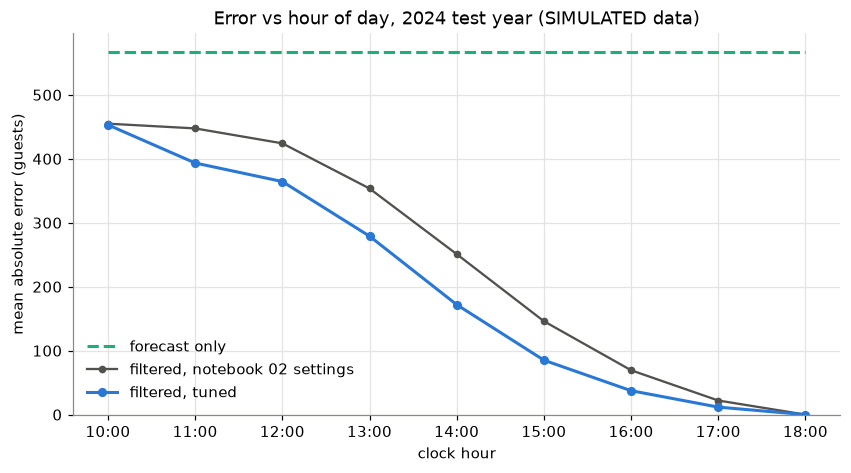

In [11]:
hrs = final.index
fig, ax = plt.subplots()
ax.plot(hrs, final["mae_forecast"], color=COLORS["forecast"], ls="--", label="forecast only")
ax.plot(hrs, baseline_nb02["mae_filtered"], color=COLORS["muted"], marker="o", ms=4, lw=1.5,
        label="filtered, notebook 02 settings")
ax.plot(hrs, final["mae_filtered"], color=COLORS["estimate"], marker="o", label="filtered, tuned")
ax.set_xticks(hrs)
ax.set_xticklabels([f"{h}:00" for h in hrs])
ax.set_ylim(0, None)
ax.set_xlabel("clock hour")
ax.set_ylabel("mean absolute error (guests)")
ax.set_title("Error vs hour of day, 2024 test year (SIMULATED data)")
ax.legend()
plt.show()

## Summary

**Result.** On the held-out 2024 year, the filtered estimate beats forecast-only
**at every hour from the first reading onward**. The gain is already meaningful in
the late morning and becomes most of the error by early afternoon (see the table
above). 18:00 is trivially perfect because the closing count *is* the final total.
The decision-relevant window is roughly 11:00–15:00.

**Decisions made (on the 2023 validation year, never on the test year)**

| Knob | Choice | Why |
| --- | --- | --- |
| `R_t` scheme | relative, `(s_t × x⁻)²` | constant `R` is worse than no filter in the morning; relative beats absolute early |
| arrival curve | one per day type (peak / regular) | weekend crowds arrive later; known before opening |
| process noise `q` and `R` inflation `k` | chosen by a fixed rule on 2023 (Section 5) | both compensate for within-day correlated errors; together they lower midday error and fix coverage |

**Honest caveats**

* **The 2024 band is slightly wide** (coverage 96–99% against a 95% target). Settings
  tuned on one year don't transfer perfectly to the next. That's normal, and it's why
  the test year is scored only once.
* **Correlated errors are patched, not solved.** `k` and `q` widen the band to fix
  coverage. They don't give the filter any new information. Notebook 04 models
  the cause (the day's arrival pace).
* **Simulated data flatters the setup:** the simulator's arrival curve shape is the
  same family the filter assumes. Real gate data will be messier (tour groups, gate
  outages, re-entries), and `f_t`, `R_t` and `q` must be refitted on production rows
  (`SOURCE = "production"`).
* **The prior is deliberately weak** (±20%). A stronger forecast (the
  Attendance-Projections model) would lower the morning error further; the filter's
  *relative* improvement would shrink, but the combined result would be better.